# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [52]:
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [53]:
X_test

,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Genero_encoded,Pais_GERMANY,Pais_SPAIN
0,686,36.0,3,95848.58,2,0.0,1.0,7144694.0,1,0,0
1,703,35.0,1,0.00,1,1.0,1.0,14136462.0,1,0,0
2,730,26.0,6,0.00,1,1.0,1.0,1011687.0,1,0,1
3,675,33.0,6,0.00,2,0.0,1.0,1011687.0,0,0,0
4,754,24.0,3,121513.31,2,0.0,1.0,1011687.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
24922,786,37.0,4,0.00,2,0.0,1.0,1011687.0,0,0,1
24923,592,35.0,7,122724.50,1,1.0,1.0,17773874.0,1,0,0
24924,645,45.0,7,121286.32,1,1.0,1.0,869372.0,1,0,0
24925,567,47.0,1,126447.40,1,1.0,0.0,1011687.0,0,1,0


In [54]:
y_test

,Churn
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
24922,0.0
24923,0.0
24924,0.0
24925,1.0


In [55]:
X_train

,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Genero_encoded,Pais_GERMANY,Pais_SPAIN
0,711,35.000000,10,0.000000,2,1.000000,0.000000,5331178.0,1,0,0
1,619,33.000000,7,0.000000,2,0.000000,1.000000,1011687.0,1,0,0
2,841,54.000000,4,102721.490000,1,1.000000,1.000000,1011687.0,1,1,0
3,679,48.000000,6,125161.240000,1,1.000000,0.000000,579659.0,1,0,0
4,656,42.000000,6,0.000000,3,0.000000,0.000000,14233155.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
117945,529,43.000000,7,0.000000,1,0.514157,0.000000,1011687.0,1,0,1
117946,639,44.450575,7,0.000000,1,1.000000,0.725287,1011687.0,0,0,1
117947,541,49.890057,6,102744.063633,1,1.000000,0.000000,1011687.0,0,1,0
117948,593,37.911470,5,139949.785268,1,1.000000,0.000000,1011687.0,0,1,0


In [56]:
y_train

,Churn
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
117945,1.0
117946,1.0
117947,1.0
117948,1.0


In [57]:
contagem_classes = y_train.value_counts()

print("Contagem de amostras por classe:")
print(contagem_classes)

Contagem de amostras por classe:
Churn
0.0      58975
1.0      58975
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

In [ ]:
'''
O algoritmo aprende as regras de decisão dividindo os dados em nós
baseados em caracteristicas que melhor separam as classes (Gini).

O modelo aplica essas regras aos dados de teste para prever oi resultado.

A avaliação se faz por meio de métricas como: Acurácia, Matriz de confusão, Classificação
(precision, recall e F1), para observar como o modelo saiu.

Podemos ajustar hiperparametros como limitar a profundidade máxima
da árvore (max_depth) para evitar overfitting (ou seja quando o modelo decora o treino
mas erra no teste)

'''

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [68]:
arvore_decisao = DecisionTreeClassifier(criterion = 'gini', random_state=0)
arvore_decisao.fit(X_train, y_train)
y_pred_train = arvore_decisao.predict(X_train)
acuracia_train = accuracy_score(y_train, y_pred_train)

print(f"Acurácia na base de treino: {acuracia_train:.4f}")

Acurácia na base de treino: 0.9997


In [69]:
arvore_decisao = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=5,           # Limita a profundidade
    min_samples_leaf=10,   # Exige mais dados para criar uma regra
    random_state=0
)

arvore_decisao.fit(X_train, y_train)

y_pred_train = arvore_decisao.predict(X_train)
acuracia_train = accuracy_score(y_train, y_pred_train)

print(f"Acurácia na base de treino: {acuracia_train:.4f}")

Acurácia na base de treino: 0.8445


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [70]:
y_pred_test = arvore_decisao.predict(X_test)
acuracia_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia na base de teste: {acuracia_test:.4f}")
print(f"Classificação Report (teste):\n {classification_report(y_test, y_pred_test)}")

Acurácia na base de teste: 0.8177
Classificação Report (teste):
               precision    recall  f1-score   support

         0.0       0.92      0.84      0.88     19649
         1.0       0.55      0.72      0.62      5278

    accuracy                           0.82     24927
   macro avg       0.74      0.78      0.75     24927
weighted avg       0.84      0.82      0.83     24927



In [ ]:
'''
foi necessário ajustar (poda), pois com a acurácia próxima do 1.0 e do teste 
muito abaixo, quer dizer que o modelo estava sofrendo overfiting.
'''

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

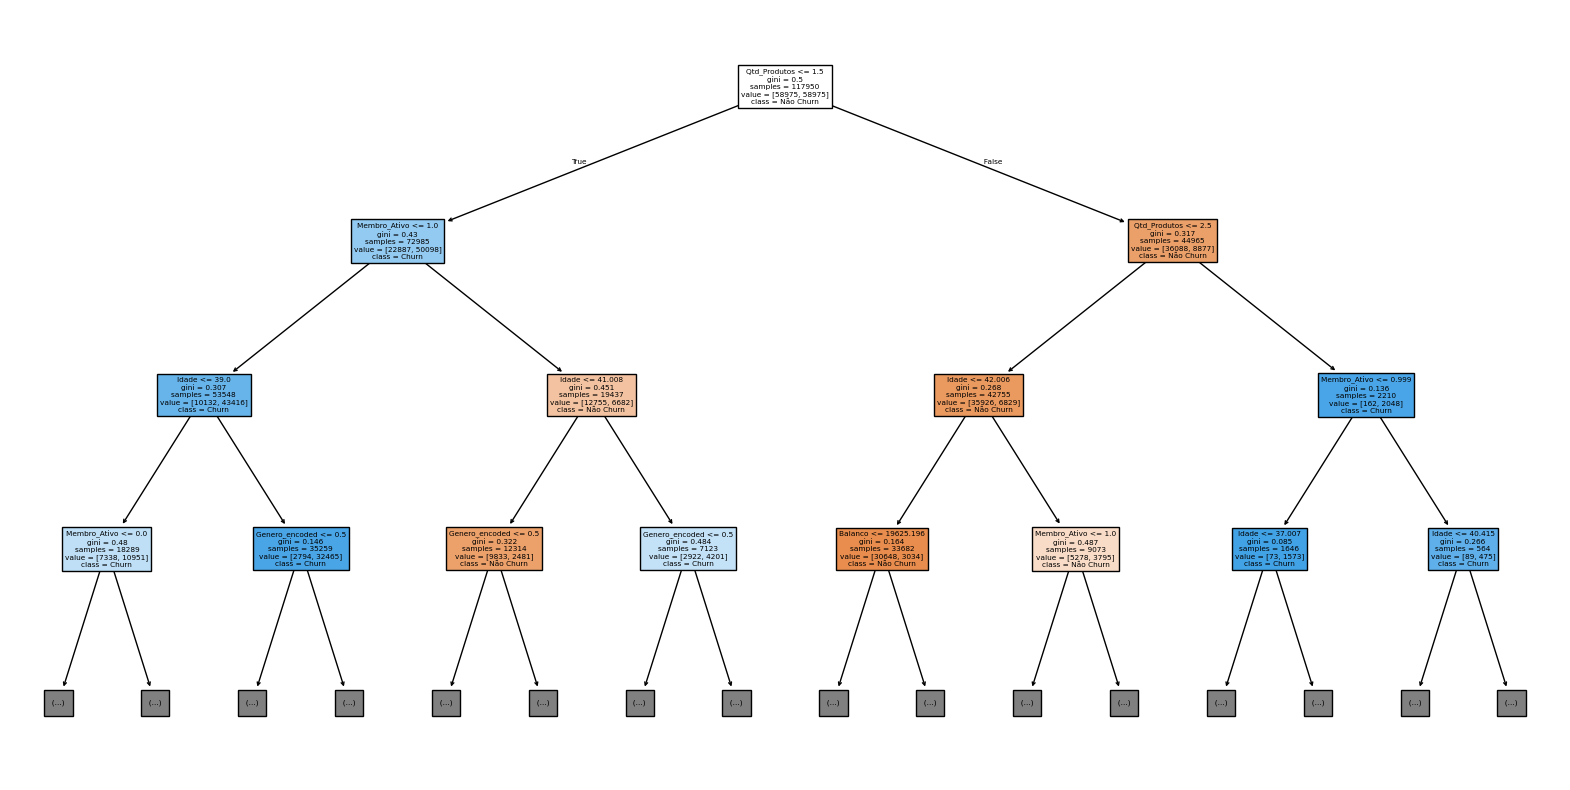

Profundidade da árvore: 5


In [71]:
plt.figure(figsize=(20,10))
plot_tree(arvore_decisao, filled=True, feature_names=X_train.columns, max_depth=3, class_names=['Não Churn', 'Churn'])
plt.show()
print(f"Profundidade da árvore: {arvore_decisao.get_depth()}")

In [ ]:
'''
Limitei a visualização (max_depth=3) para ser legível, pois árvores completas costumam ser gigantescas.
'''

# 6) Identifique as 2 principais features do modelo.


In [72]:
importances = pd.DataFrame({'feature': X_train.columns, 'importance': arvore_decisao.feature_importances_})
importances = importances.sort_values(by='importance', ascending=False)
print("As 2 principais features são:")
print(importances.head(2))

As 2 principais features são:
        feature  importance
4  Qtd_Produtos    0.479612
6  Membro_Ativo    0.295563


# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [73]:
top_features = importances['feature'].head(2).tolist()
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

arvore_decisao_top = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore_decisao_top.fit(X_train_top, y_train)

# Avaliação
y_pred_top = arvore_decisao_top.predict(X_test_top)
print(f"Nova Acurácia (2 features): {accuracy_score(y_test, y_pred_top):.4f}")

Nova Acurácia (2 features): 0.7840


# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [ ]:
'''
O Naive Bayes falhou devido à sua premissa básica de que variáveis como Idade 
e Salário são independentes entre si, o que não reflete a realidade financeira. 
Já a Árvore de Decisão conseguiu capturar as interações não-lineares entre 
essas variáveis, resultando em previsões mais precisas.

A Árvore de Decisão se adequou melhor aos dados por conseguir lidar com a complexidade
e as correlações presentes nas características dos clientes, sendo o modelo mais
indicado para a operação de crédito em questão.
'''